In [1]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, compatible_TimeSeries_check, print_wise, get_lagplot
# from useful_stuff.general_utils.RSA import  dRSA
# from useful_stuff.general_utils.II import  dRSA, dynInformationImbalance
from useful_stuff.general_utils.regression import  dyn_linear_encoding
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from project_specific_utils.dataloader import load_meg_data, load_eyetracking_data, load_concat_regressout_meg, load_concat_regressout_mod, load_concat_gaze
from project_specific_utils.utils import subsampling_lagged_comparisons, subsampling_RSA, subsampling_II, subsampling_encoding, save_lagged_comparisons
from image_processing.gaze_dep_models import save_ANN_features


In [2]:
def plot_rsa(tot_rsa, neu_fs, max_lag, title=None, tick_step=20):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # --- heatmap ---
    ax[0].imshow(tot_rsa)

    ticks = np.arange(-max_lag, max_lag + 1, tick_step)
    ticks_labels = np.round(ticks / neu_fs, 2)
    ticks += max_lag

    # --- lag plot ---
    lagplot = get_lagplot(tot_rsa, max_lag=max_lag)
    ax[1].plot(lagplot)

    ax[1].set_ylabel("dRSA similarity")
    ax[1].set_xlabel("lag [sec]")
    ax[1].set_xticks(ticks, ticks_labels)
    ax[1].axvline(max_lag, color="r", linestyle="--", linewidth=1)

    # --- 🔥 compute peak ---
    peak_idx = np.argmax(lagplot)
    peak_val = lagplot[peak_idx]
    peak_lag = (peak_idx - max_lag) / neu_fs  # convert to seconds

    # --- 🔥 textbox ---
    textstr = f"magnitude: {peak_val:.3f}\nlag: {peak_lag:.2f}s"
    ax[1].text(
        0.05, 0.95, textstr,
        transform=ax[1].transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

    # --- labels ---
    ax[0].set_xlabel(f"Model time, length={tot_rsa.shape[1]/neu_fs}sec")
    ax[0].set_ylabel(f"Neural time, length={tot_rsa.shape[1]/neu_fs}sec")
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    fig.suptitle(title, fontsize=20)
    plt.tight_layout()



In [8]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 3
    neu_fs = 100
    gaze_fs = 50
    sq_side = 384
    sensors_group = 'occ'
    model_name = "alexnet" 
    pkg = "torchvision"
    pseudotrial_len = 600
    pseudotrials_n = 100
    full_model_name = "alexnet_features.4"
    n_model_components = 1000
    pooling = "all"
    PCs_to_regress_out = 50
    timepts_to_regress_out = (-100, 100)
    iterations_n = 1000
    repetition = 0
    signal_metric = "correlation"
    model_metric = "correlation"
    regress_out_gaze = 'PCR' # or None or pointwise
    PCs_to_regress_out = 50
    analysis_type = "RSA"
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
mod_fs = config["movie_fs"]
model_len = [round(i*cfg.neu_fs/config["movie_fs"]) for i in config["model_len"]]

In [9]:
def multivariate_lagged_comparisons(paths, n, analysis_type, sub_num, sensors_group, repetition, full_model_name, iterations_n, pseudotrial_len, neu_fs, signal_metric, model_metric, pseudotrials_n, sq_side, regress_out_gaze, n_model_components, pooling="all", rank=0):
    if cfg.analysis_type == "RSA":
        p = [save_lagged_comparisons(paths, analysis_type, sub_num, sensors_group, i_rep, full_model_name, iterations_n, pseudotrial_len, neu_fs, signal_metric=signal_metric, model_metric=model_metric, pseudotrials_n=pseudotrials_n, sq_side=sq_side, regress_out_gaze=regress_out_gaze),]
    elif cfg.analysis_type == "II":
        p = []
        pA2B = save_lagged_comparisons(paths, analysis_type+"A2B", sub_num, sensors_group, i_rep, full_model_name, iterations_n, pseudotrial_len, neu_fs, signal_metric=signal_metric, model_metric=model_metric, pseudotrials_n=pseudotrials_n, sq_side=sq_side, regress_out_gaze=regress_out_gaze)
        p.append(pA2B)
        pB2A = save_lagged_comparisons(paths, cfg.analysis_type+"B2A", sub_num, sensors_group, i_rep, full_model_name, iterations_n, pseudotrial_len, neu_fs, signal_metric=signal_metric, model_metric=model_metric, pseudotrials_n=pseudotrials_n, sq_side=sq_side, regress_out_gaze=regress_out_gaze)
        p.append(pB2A)
    if all(os.path.exists(path) for path in p):
        print(f"{p[0]} already exists")
        return None
    m = load_concat_regressout_mod(paths, sub_num, save_ANN_features, full_model_name, repetition, mod_fs, neu_fs, *(sq_side, n_model_components, pooling), regress_out_gaze=False, gaze_dep=True, gaze_fs=50, rank=rank,)
    tot_A2B, tot_B2A = subsampling_lagged_comparisons(n, m, pseudotrial_len, iterations_n, pseudotrials_n, model_len, subsampling_RSA, rank, *(signal_metric, model_metric))
    if not cfg.regress_out_gaze:
        cfg.regress_out_gaze = "0"
    if cfg.analysis_type == "RSA":
        savemat(p[0], {"RSA": tot_A2B})
        print_wise(f"{full_model_name} saved at {p[0]}")
    elif cfg.analysis_type == "II":
        savemat(p[0], {"II": tot_A2B})
        savemat(p[1], {"II": tot_B2A})
        print_wise(f"{full_model_name} saved at {p[0]}")
    return None

In [ ]:
from scipy.io import savemat
repetitions = [0,1]
rank = 0
for i_rep in repetitions:
    n = load_concat_regressout_meg(paths, cfg.sub_num, i_rep, cfg.sensors_group, cfg.neu_fs, cfg.gaze_fs, cfg.regress_out_gaze, cfg.PCs_to_regress_out, timepts_to_regress_out=cfg.timepts_to_regress_out, rank=0)
    for l in get_relevant_output_layers(cfg.model_name, pkg=cfg.pkg):
        full_model_name = f"{cfg.model_name}_{l}"
        multivariate_lagged_comparisons(paths, n, cfg.analysis_type, cfg.sub_num, cfg.sensors_group, i_rep, full_model_name, cfg.iterations_n, cfg.pseudotrial_len, cfg.neu_fs, cfg.signal_metric, cfg.model_metric, cfg.pseudotrials_n, cfg.sq_side, cfg.regress_out_gaze, cfg.n_model_components, rank=rank)

10:40:24 - rank 0 Loading MEG signal: regress_out_gaze='PCR'
10:40:25 - rank 0 Shape runs [1 2 3]: [(41, 87379), (41, 86278), (41, 79071)]
10:40:25 - rank 0 Loading model alexnet_features.0: regress_out_gaze=False
10:40:26 - rank 0 alexnet_features.0: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
10:40:26 - rank 0 starting iteration 0 of 999
10:40:37 - rank 0 starting iteration 10 of 999
10:40:47 - rank 0 starting iteration 20 of 999
10:40:58 - rank 0 starting iteration 30 of 999
10:41:09 - rank 0 starting iteration 40 of 999
10:41:20 - rank 0 starting iteration 50 of 999
10:41:30 - rank 0 starting iteration 60 of 999
10:41:42 - rank 0 starting iteration 70 of 999


In [28]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
m = loadmat("/Users/tizianocausin/1917_local/results/RSA_sub003_occ_rep0_vit_l_16_blocks.1.mlp.fc2_correlation-correlation_100iter_100pst_len_6s_384x384patch_regr_out_gaze_PCR.mat")
plot_rsa(m["RSA"], 100, 300, tick_step = 40)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/tizianocausin/1917_local/results/RSA_sub003_occ_rep0_vit_l_16_blocks.1.mlp.fc2_correlation-correlation_100iter_100pst_len_6s_384x384patch_regr_out_gaze_PCR.mat'

In [ ]:
full_model_name = "alexnet_features.0"
p = save_lagged_comparisons(paths, cfg.analysis_type+"A2B", cfg.sub_num, cfg.sensors_group, full_model_name, cfg.iterations_n, cfg.pseudotrial_len, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.signal_metric, pseudotrials_n= cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
print(p)

/Users/tizianocausin/1917_local/results/IIA2B_sub003_occ_alexnet_features.0_cosine_cnt-cosine_cnt_100iter_50pst_len_6s_384x384patch_regr_out_gaze_PCR.mat


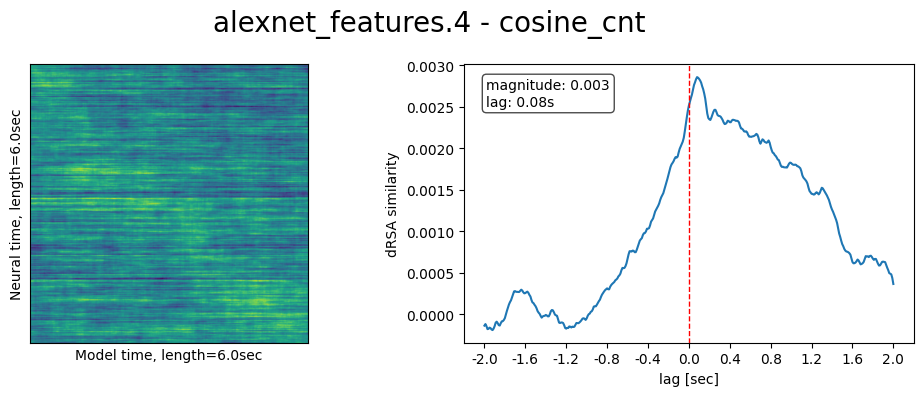

In [19]:
plot_rsa(tot_rsa, cfg.neu_fs, cfg.max_lag, f"{cfg.full_model_name} - {cfg.RDM_metric}", tick_step=40)

In [14]:
tot_II_A2B, tot_II_B2A = subsampling_lagged_comparisons(neu, mod, cfg.time_points, cfg.iterations_n-80, cfg.pseudotrials_n, len_mod, subsampling_II, 0, *(cfg.RDM_metric, cfg.RDM_metric),**{"k": 20})

19:32:48 - rank 0 starting iteration 0 of 19
19:33:32 - rank 0 starting iteration 10 of 19


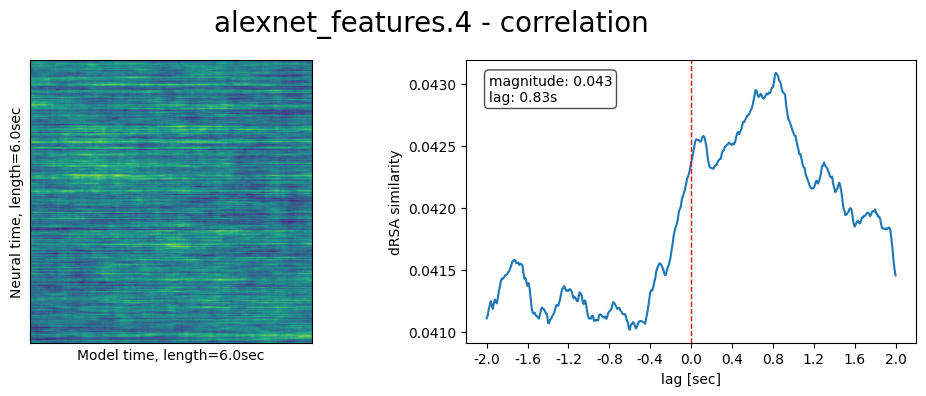

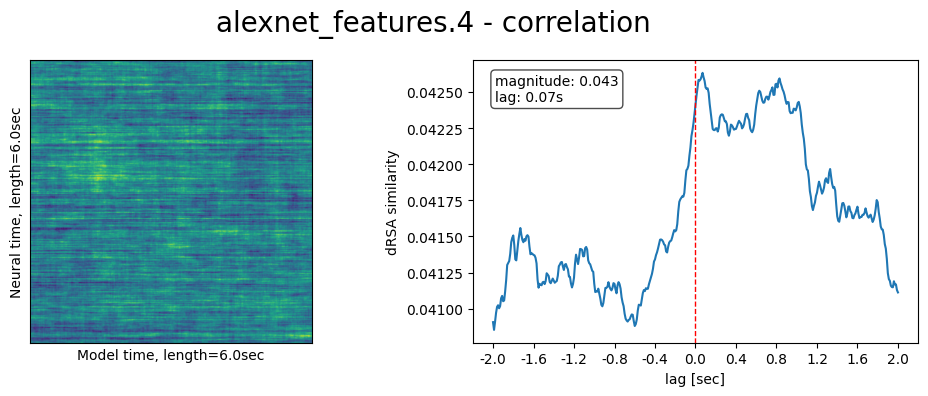

In [15]:
plot_rsa(1-tot_II_A2B, cfg.neu_fs, cfg.max_lag, f"{cfg.full_model_name} - {cfg.RDM_metric}", tick_step=40)
plot_rsa(1-tot_II_B2A, cfg.neu_fs, cfg.max_lag, f"{cfg.full_model_name} - {cfg.RDM_metric}", tick_step=40) #TODO check if the dynII is correct in its timecourse...

In [27]:
print(cfg.pseudotrials_n)

50


In [46]:
r = subsampling_lagged_comparisons('encoding', neu, mod, cfg.time_points, cfg.iterations_n - 99, cfg.pseudotrials_n, subsampling_encoding, 0, *('ridge', 'kf', 5),**{"score_type": "corr", "n_splits": 2, }) 

12:40:25 - rank 0 starting iteration 0 of 0
(1, 11)


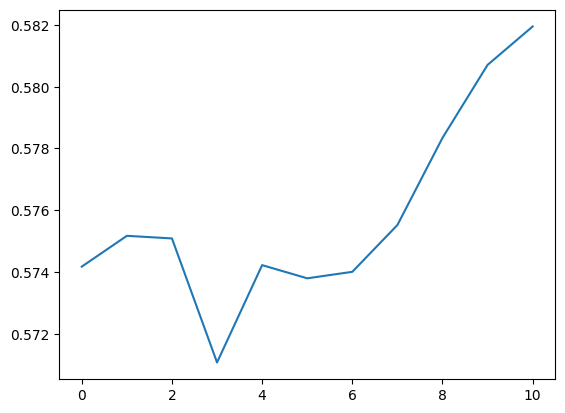

In [47]:
plt.plot(r.T);